# Text Classification: Effect of Dropout and L2 Regularization

Steps: load dataset → text vectorization → simple neural network → train without regularization → add Dropout → add L2 → compare.

Keep `dataset.csv` in the same folder as this notebook.

## 1. Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers

SEED = 42
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

I0000 00:00:1790653705.442840    2388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790653707.084206    2388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 2. Load the dataset (two classes: 0 = negative, 1 = positive)

In [2]:
df = pd.read_csv("dataset.csv")
print(df.shape)
print(df["label"].value_counts())
df.head()

(400, 2)
label
0    205
1    195
Name: count, dtype: int64


,text,label
0,"Such a disappointing the hotel, it failed my e...",0
1,"Absolutely enjoyed the hotel, truly a great va...",1
2,"What a terrible the course, the quality is poo...",0
3,"Awful experience with this phone, the design i...",1
4,"Such a wonderful the hotel, the quality is exc...",1


## 3. Train / validation split

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    df["text"].values, df["label"].values,
    test_size=0.3, stratify=df["label"], random_state=SEED
)
print("Train:", len(X_train), " Validation:", len(X_val))

Train: 280  Validation: 120


## 4. Text vectorization
The vocabulary is learned (`adapt`) on the training data only, then text is converted to integer sequences.

In [4]:
MAX_TOKENS = 500   # vocabulary size limit
SEQ_LEN = 20       # every sentence padded/truncated to 20 tokens

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=SEQ_LEN
)
vectorizer.adapt(X_train)

Xtr = vectorizer(X_train).numpy()
Xva = vectorizer(X_val).numpy()

print("Vocabulary size:", len(vectorizer.get_vocabulary()))
print("Sample text  :", X_train[0])
print("Sample vector:", Xtr[0])

Vocabulary size: 103
Sample text  : I really loved this book, best purchase this year although the quality is poor.
Sample vector: [ 6 42 96  3 36 67 14  3 13  4  2 20  7 47  0  0  0  0  0  0]


## 5. Build a simple neural network
One function builds the model; `dropout` and `l2` are switched on only when needed, so all three experiments use the same architecture.

In [5]:
def build_model(dropout=0.0, l2=0.0):
    reg = regularizers.l2(l2) if l2 > 0 else None
    layer_list = [
        layers.Input(shape=(SEQ_LEN,)),
        layers.Embedding(MAX_TOKENS, 64),
        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
    ]
    if dropout > 0:
        layer_list.append(layers.Dropout(dropout))
    layer_list.append(layers.Dense(64, activation="relu", kernel_regularizer=reg))
    if dropout > 0:
        layer_list.append(layers.Dropout(dropout))
    layer_list.append(layers.Dense(1, activation="sigmoid"))

    model = tf.keras.Sequential(layer_list)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,289 (798.00 KB)

 Trainable params: 204,289 (798.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train WITHOUT regularization (baseline)

In [6]:
EPOCHS = 30
BATCH = 16
histories = {}

tf.keras.utils.set_random_seed(SEED)
model_base = build_model()
histories["No Regularization"] = model_base.fit(
    Xtr, y_train, validation_data=(Xva, y_val),
    epochs=EPOCHS, batch_size=BATCH, verbose=0
).history

h = histories["No Regularization"]
print(f"Train acc {h['accuracy'][-1]:.3f} | Val acc {h['val_accuracy'][-1]:.3f} | "
      f"Train loss {h['loss'][-1]:.3f} | Val loss {h['val_loss'][-1]:.3f}")

Train acc 0.996 | Val acc 0.867 | Train loss 0.007 | Val loss 1.253


## 7. Add Dropout and train again

In [7]:
tf.keras.utils.set_random_seed(SEED)
model_drop = build_model(dropout=0.5)
histories["Dropout (0.5)"] = model_drop.fit(
    Xtr, y_train, validation_data=(Xva, y_val),
    epochs=EPOCHS, batch_size=BATCH, verbose=0
).history

h = histories["Dropout (0.5)"]
print(f"Train acc {h['accuracy'][-1]:.3f} | Val acc {h['val_accuracy'][-1]:.3f} | "
      f"Train loss {h['loss'][-1]:.3f} | Val loss {h['val_loss'][-1]:.3f}")

Train acc 0.982 | Val acc 0.883 | Train loss 0.052 | Val loss 1.062


## 8. Add L2 regularization and train again

In [8]:
tf.keras.utils.set_random_seed(SEED)
model_l2 = build_model(l2=0.01)
histories["L2 (0.01)"] = model_l2.fit(
    Xtr, y_train, validation_data=(Xva, y_val),
    epochs=EPOCHS, batch_size=BATCH, verbose=0
).history

h = histories["L2 (0.01)"]
print(f"Train acc {h['accuracy'][-1]:.3f} | Val acc {h['val_accuracy'][-1]:.3f} | "
      f"Train loss {h['loss'][-1]:.3f} | Val loss {h['val_loss'][-1]:.3f}")

Train acc 0.964 | Val acc 0.867 | Train loss 0.198 | Val loss 0.617


## 9. Compare training vs validation accuracy / loss (table)

In [9]:
summary = pd.DataFrame({
    name: {
        "Train Acc": h["accuracy"][-1],
        "Val Acc": h["val_accuracy"][-1],
        "Train Loss": h["loss"][-1],
        "Val Loss": h["val_loss"][-1],
        "Acc Gap (train-val)": h["accuracy"][-1] - h["val_accuracy"][-1],
        "Loss Gap (val-train)": h["val_loss"][-1] - h["loss"][-1],
    }
    for name, h in histories.items()
}).T.round(4)
summary

,Train Acc,Val Acc,Train Loss,Val Loss,Acc Gap (train-val),Loss Gap (val-train)
No Regularization,0.9964,0.8667,0.0069,1.2526,0.1298,1.2457
Dropout (0.5),0.9821,0.8833,0.0523,1.0620,0.0988,1.0097
L2 (0.01),0.9643,0.8667,0.1980,0.6172,0.0976,0.4192


## 10. Compare (plots): each model's train vs validation curves

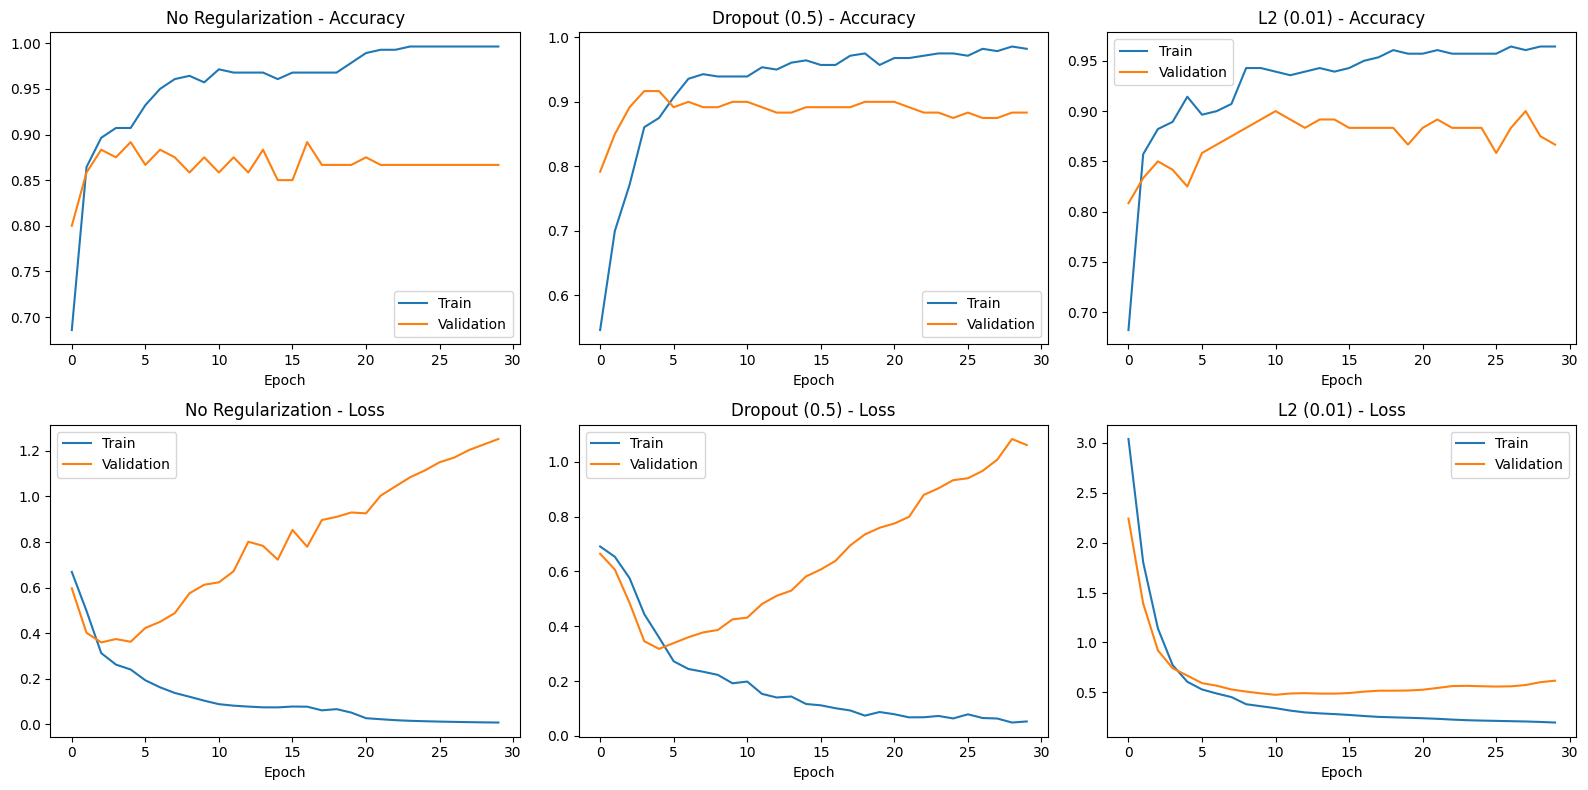

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, (name, h) in enumerate(histories.items()):
    axes[0, col].plot(h["accuracy"], label="Train")
    axes[0, col].plot(h["val_accuracy"], label="Validation")
    axes[0, col].set_title(f"{name} - Accuracy")
    axes[0, col].set_xlabel("Epoch"); axes[0, col].legend()

    axes[1, col].plot(h["loss"], label="Train")
    axes[1, col].plot(h["val_loss"], label="Validation")
    axes[1, col].set_title(f"{name} - Loss")
    axes[1, col].set_xlabel("Epoch"); axes[1, col].legend()
plt.tight_layout()
plt.show()

## 11. Compare (plots): validation curves of all three models together

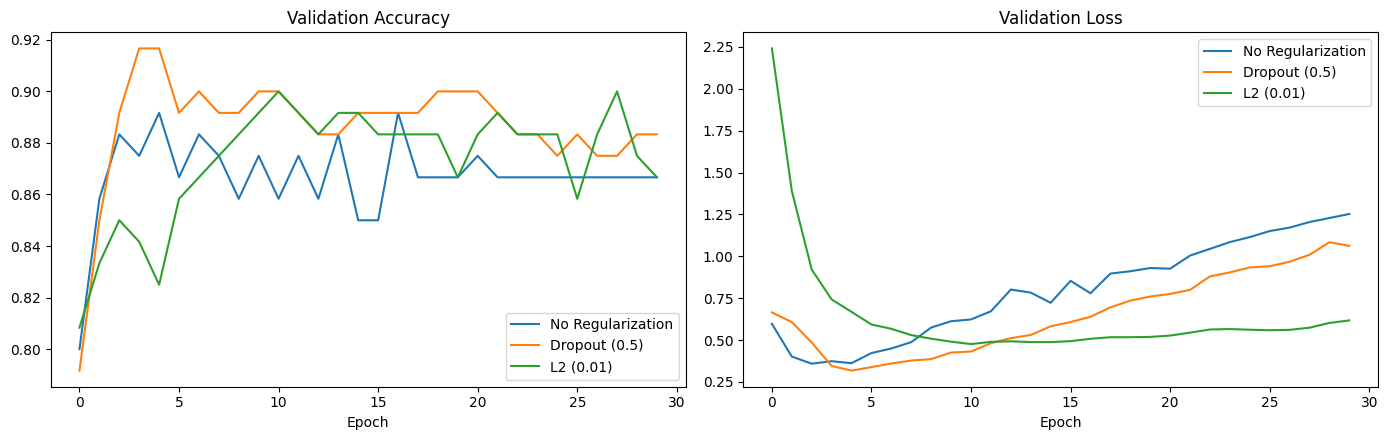

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for name, h in histories.items():
    ax[0].plot(h["val_accuracy"], label=name)
    ax[1].plot(h["val_loss"], label=name)
ax[0].set_title("Validation Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].set_title("Validation Loss");     ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.show()

## 12. Conclusion

- **No regularization:** training accuracy reaches ~100% but validation accuracy is lower and validation loss keeps rising → the model memorizes the (noisy) training data, i.e. **overfitting**.
- **Dropout:** randomly switching off neurons reduces the train–validation gap and gives a better validation accuracy.
- **L2:** penalizing large weights gives the lowest validation loss, so predictions are less over-confident.
- Both techniques reduce overfitting; the validation loss curves show the difference most clearly (the validation set is small, so small accuracy differences are within noise).